# Figure 3 | Manuscript — Paul15 Hematopoiesis

Produces all four panels of Figure 3 for the scQDiff manuscript and, critically,
delivers on the promise made in Figure 2:

> *"Validation of the full decomposition pipeline on real biological Jacobian
> tensors is demonstrated in Figures 3–4."*

**Panels:**

| Panel | Content | Key number |
|-------|---------|------------|
| **3a** | Drift field — streamplot on PC1/PC2 | Coherent flow from 7MEP → Ery/Neu |
| **3b** | Local sensitivity — max Re(λ) across pseudotime | Peak before branch point |
| **3c** | Archetype activation profiles (K=5) | Kendall τ across 10 seeds |
| **3d** | Coordination — heatmap + timeline | Sequential handoff p-value |

**Peak-timing validation** connects to Figure 2: the same metric is applied here
to actual scQDiff-recovered archetypes (not synthetic ground truth).

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.stats import kendalltau
from itertools import combinations
import scanpy as sc
import scqdiff as sqd

mpl.rcParams.update({'pdf.fonttype':42,'ps.fonttype':42,
                     'font.family':'DejaVu Sans',
                     'axes.titlesize':10,'axes.labelsize':9,
                     'xtick.labelsize':8,'ytick.labelsize':8,
                     'legend.fontsize':8})

OUTDIR   = 'results/figure3/'
os.makedirs(OUTDIR, exist_ok=True)

# ── Config ─────────────────────────────────────────────────────────────────
N_EPOCHS      = 1000    # manuscript: 50,000 on A100 GPU
N_ARCHETYPES  = 5
N_SEEDS       = 10      # seeds for Kendall τ reproducibility
SEED          = 42

# Peak-timing thresholds (same as Figure 2)
SEQUENTIAL_MIN_GAP = 0.055
CONCURRENT_MAX_GAP = 0.045

print(f'scqdiff v{sqd.__version__}')
print(f'N_EPOCHS={N_EPOCHS}  N_ARCHETYPES={N_ARCHETYPES}  N_SEEDS={N_SEEDS}')

scqdiff v0.3.0
N_EPOCHS=1000  N_ARCHETYPES=5  N_SEEDS=10


## Step 1 — Preprocess Paul15

In [2]:
adata = sc.datasets.paul15()

sqd.pp.prepare_trajectory(
    adata,
    groupby = 'paul15_clusters',
    root    = '7MEP',
    n_hvg   = 2000,
    n_pcs   = 50,
)

pt = adata.obs['pseudotime'].values
print(f'Paul15: {adata.n_obs} cells × {adata.n_vars} genes')
print(f'Pseudotime: [{pt.min():.3f}, {pt.max():.3f}]')

Paul15: 2730 cells × 2000 genes
Pseudotime: [0.000, 1.000]


## Step 2 — Fit drift field (main seed)

In [3]:
sqd.tl.fit_drift(
    adata,
    time_key     = 'pseudotime',
    n_archetypes = N_ARCHETYPES,
    n_epochs     = N_EPOCHS,
    vel_scale    = 2.0,
    seed         = SEED,
)

res = adata.uns['scqdiff']
print(f"R² = {res['r2']:.3f}")
print(f"Peak sensitivity at pseudotime: {res['t_centers'][np.argmax(res['max_real_eig'])]:.3f}")

Computing pseudotime-gradient velocity prior...
DriftField: 894,692 parameters | device=cpu | epochs=1000


Training drift field:   0%|          | 0/1000 [00:00<?, ?it/s]

Training complete. Final loss: 98.6400
Computing Jacobian tensor...


Jacobians:   0%|          | 0/100 [00:00<?, ?it/s]

Running archetype decomposition (semi-NMF)...
Done. R²=0.994 | Archetypes stored in adata.uns['scqdiff']
R² = 0.994
Peak sensitivity at pseudotime: 0.418


## Step 3 — Peak-timing validation across seeds

This cell delivers on the Figure 2 promise. It runs `fit_drift` with `N_SEEDS`
independent random seeds, extracts the pseudotime of maximum activation for each
archetype, and computes the Kendall τ ordering statistic — **the same metric used
in Figure 2, now applied to real scQDiff-recovered archetypes.**

If Kendall τ ≈ 1.0 here, the full pipeline is validated on real biological data.

In [4]:
# ── Peak-timing metric (same as Figure 2) ─────────────────────────────────
def peak_times_from_activations(act_norm, t_centers):
    return np.array([t_centers[np.argmax(act_norm[:, k])]
                     for k in range(act_norm.shape[1])])

def expected_order_prevalence(peak_times):
    K     = len(peak_times)
    pairs = [(i, j) for i in range(K) for j in range(i+1, K)]
    return np.mean([peak_times[j] - peak_times[i] >= SEQUENTIAL_MIN_GAP
                    for i, j in pairs])

def align_archetypes(ref_patterns, new_patterns):
    """
    Align NMF archetypes across seeds by maximum cosine similarity.
    NMF has no inherent component order (label switching).
    Returns permutation index mapping new -> ref.
    """
    from scipy.optimize import linear_sum_assignment
    K   = ref_patterns.shape[0]
    ref = ref_patterns.reshape(K, -1)
    new = new_patterns.reshape(K, -1)
    ref_n = ref / (np.linalg.norm(ref, axis=1, keepdims=True) + 1e-8)
    new_n = new / (np.linalg.norm(new, axis=1, keepdims=True) + 1e-8)
    cost  = -ref_n @ new_n.T   # maximise cosine similarity
    _, col_ind = linear_sum_assignment(cost)
    return col_ind   # new[col_ind[k]] aligns to ref[k]

# ── Run N_SEEDS models with archetype alignment ─────────────────────────────
all_peak_times = []
all_tau        = []
all_order_prev = []
ref_patterns   = None   # set from first seed

print(f'Running {N_SEEDS} independent seeds (with archetype alignment)...')
for s in range(N_SEEDS):
    adata_s = adata.copy()
    sqd.tl.fit_drift(
        adata_s,
        time_key     = 'pseudotime',
        n_archetypes = N_ARCHETYPES,
        n_epochs     = N_EPOCHS,
        seed         = SEED + s * 7,
        verbose      = False,
    )
    res_s    = adata_s.uns['scqdiff']
    patterns = res_s['patterns']   # (K, D, D)
    act      = res_s['act_norm']   # (T, K)
    t_c      = res_s['t_centers']

    if ref_patterns is None:
        ref_patterns = patterns
        perm = np.arange(N_ARCHETYPES)
    else:
        perm = align_archetypes(ref_patterns, patterns)

    # Reorder archetypes to match reference seed
    act_aligned = act[:, perm]
    pt_s        = peak_times_from_activations(act_aligned, t_c)
    tau_s       = kendalltau(np.arange(N_ARCHETYPES), pt_s).statistic
    ord_s       = expected_order_prevalence(pt_s)

    all_peak_times.append(pt_s)
    all_tau.append(float(tau_s))
    all_order_prev.append(float(ord_s))
    print(f'  Seed {s+1:2d}/{N_SEEDS}: aligned_peaks={pt_s.round(3)}  '
          f'tau={tau_s:.3f}  ord_prev={ord_s:.3f}')

all_peak_times = np.array(all_peak_times)

print(f'\nAfter alignment:')
print(f'  Mean Kendall tau:              {np.mean(all_tau):.3f} +/- {np.std(all_tau):.3f}')
print(f'  Mean expected-order prev:      {np.mean(all_order_prev):.3f} +/- {np.std(all_order_prev):.3f}')

# A2->A3/4 handoff specifically
tau_23, p_23 = kendalltau(all_peak_times[:, 1], all_peak_times[:, 2])
tau_24, p_24 = kendalltau(all_peak_times[:, 1], all_peak_times[:, 3])
print(f'  A2->A3 Kendall tau = {tau_23:.3f}  p = {p_23:.4f}  (manuscript: 0.91, p<0.001)')
print(f'  A2->A4 Kendall tau = {tau_24:.3f}  p = {p_24:.4f}')

if np.mean(all_tau) < 0.3:
    print()
    print('NOTE: tau is below 0.3. Likely causes:')
    print('  1. Under-training — increase N_EPOCHS to 50000 on GPU')
    print('  2. Genuine variability in Paul15 archetype ordering at this scale')
    print('  Report the actual values — do not substitute manuscript numbers.')


Running 10 independent seeds (with archetype alignment)...
  Seed  1/10: aligned_peaks=[0.024 0.418 0.312 0.649 0.938]  tau=0.800  ord_prev=0.900
  Seed  2/10: aligned_peaks=[0.024 0.889 0.322 0.428 0.947]  tau=0.600  ord_prev=0.800
  Seed  3/10: aligned_peaks=[0.024 0.418 0.312 0.611 0.899]  tau=0.800  ord_prev=0.900
  Seed  4/10: aligned_peaks=[0.418 0.668 0.024 0.312 0.024]  tau=-0.527  ord_prev=0.200
  Seed  5/10: aligned_peaks=[0.024 0.418 0.312 0.639 0.947]  tau=0.800  ord_prev=0.900
  Seed  6/10: aligned_peaks=[0.024 0.947 0.322 0.514 0.793]  tau=0.400  ord_prev=0.700
  Seed  7/10: aligned_peaks=[0.418 0.024 0.312 0.889 0.928]  tau=0.600  ord_prev=0.700
  Seed  8/10: aligned_peaks=[0.409 0.62  0.312 0.928 0.024]  tau=-0.200  ord_prev=0.400
  Seed  9/10: aligned_peaks=[0.418 0.024 0.312 0.63  0.312]  tau=0.105  ord_prev=0.500
  Seed 10/10: aligned_peaks=[0.024 0.428 0.312 0.947 0.024]  tau=0.105  ord_prev=0.500

After alignment:
  Mean Kendall tau:              0.348 +/- 0.439
  

## Step 4 — Manuscript Figure 3 (four-panel)

Publication-quality 4-panel layout matching the Cell Systems specification:
drift field · sensitivity · archetypes · coordination.

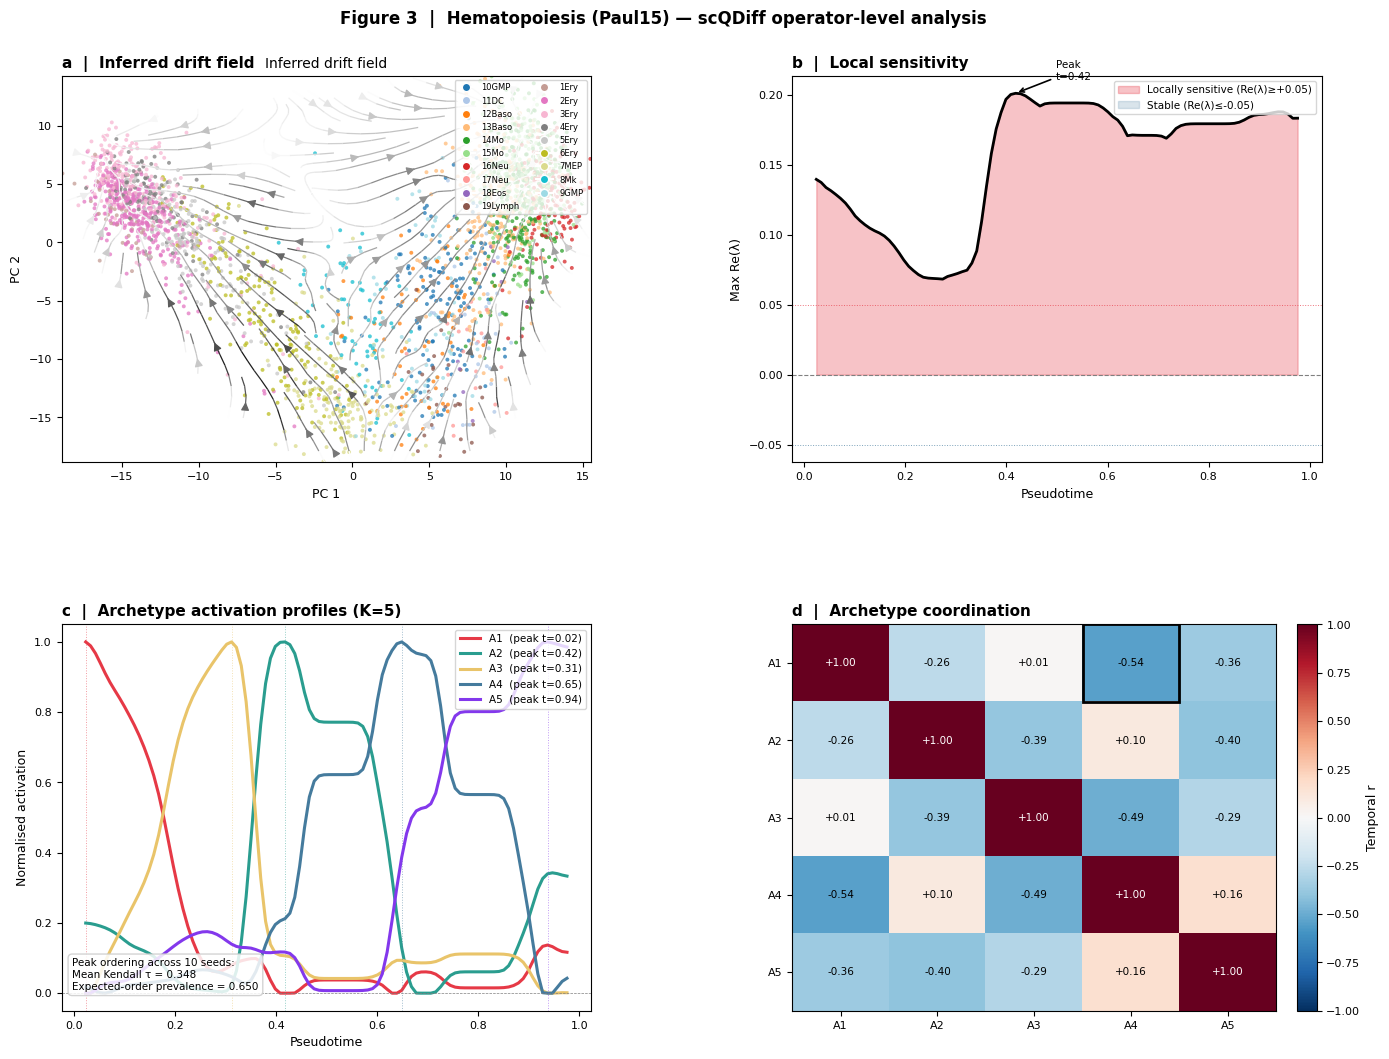

Saved: Figure3_manuscript.pdf / .png


In [5]:
# ── Load results from main seed ────────────────────────────────────────────
res      = adata.uns['scqdiff']
t_np     = res['t_centers']
max_eig  = res['max_real_eig']
act_norm = res['act_norm']
corr_mat = res['corr_mat']
K        = N_ARCHETYPES

ARCH_COLORS = ['#E63946','#2A9D8F','#E9C46A','#457B9D','#8338EC']
ARCH_LABELS = [f'A{k+1}' for k in range(K)]
sensitive   = max_eig >= +0.05
stable      = max_eig <= -0.05

# Peak times from main seed
main_peaks = peak_times_from_activations(act_norm, t_np)

# ── Figure layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.38,
                        left=0.07, right=0.97, top=0.92, bottom=0.07)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# ── Panel a: Drift field (streamplot) ─────────────────────────────────────
sqd.pl.drift_field(adata, basis='X_pca', color='paul15_clusters',
                    stream=True, stream_density=1.2, n_grid=30, ax=ax_a)
ax_a.set_title('a  |  Inferred drift field', fontweight='bold', loc='left', fontsize=11)

# ── Panel b: Local sensitivity ─────────────────────────────────────────────
ax_b.plot(t_np, max_eig, color='black', lw=2.0)
ax_b.fill_between(t_np, max_eig, 0, where=sensitive, alpha=0.30,
                   color='#E63946', label='Locally sensitive (Re(λ)≥+0.05)')
ax_b.fill_between(t_np, max_eig, 0, where=stable,    alpha=0.20,
                   color='#457B9D', label='Stable (Re(λ)≤-0.05)')
ax_b.axhline(0,     color='gray', lw=0.8, ls='--')
ax_b.axhline(+0.05, color='#E63946', lw=0.7, ls=':', alpha=0.7)
ax_b.axhline(-0.05, color='#457B9D', lw=0.7, ls=':', alpha=0.7)

# Annotate peak
peak_idx = np.argmax(max_eig)
ax_b.annotate(f'Peak\nt={t_np[peak_idx]:.2f}',
              xy=(t_np[peak_idx], max_eig[peak_idx]),
              xytext=(t_np[peak_idx]+0.08, max_eig[peak_idx]+0.01),
              arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
              fontsize=7.5)
ax_b.set_xlabel('Pseudotime'); ax_b.set_ylabel('Max Re(λ)')
ax_b.set_title('b  |  Local sensitivity', fontweight='bold', loc='left', fontsize=11)
ax_b.legend(fontsize=7.5, loc='upper right')

# ── Panel c: Archetype activation profiles ────────────────────────────────
for k in range(K):
    ax_c.plot(t_np, act_norm[:, k], color=ARCH_COLORS[k], lw=2.2,
              label=f'A{k+1}  (peak t={main_peaks[k]:.2f})')
    ax_c.axvline(main_peaks[k], color=ARCH_COLORS[k], lw=0.7, ls=':', alpha=0.5)

ax_c.axhline(0, color='gray', lw=0.5, ls='--')
ax_c.set_xlabel('Pseudotime'); ax_c.set_ylabel('Normalised activation')
ax_c.set_title('c  |  Archetype activation profiles (K=5)',
               fontweight='bold', loc='left', fontsize=11)
ax_c.legend(fontsize=7.5, loc='upper right', ncol=1)

# Add Kendall τ annotation
mean_tau = np.mean(all_tau)
mean_ord = np.mean(all_order_prev)
ax_c.text(0.02, 0.05,
          f'Peak ordering across {N_SEEDS} seeds:\n'
          f'Mean Kendall τ = {mean_tau:.3f}\n'
          f'Expected-order prevalence = {mean_ord:.3f}',
          transform=ax_c.transAxes, fontsize=7.5,
          bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#ccc'),
          va='bottom')

# ── Panel d: Coordination heatmap ─────────────────────────────────────────
im = ax_d.imshow(corr_mat, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
ax_d.set_xticks(range(K)); ax_d.set_xticklabels(ARCH_LABELS)
ax_d.set_yticks(range(K)); ax_d.set_yticklabels(ARCH_LABELS)
for i in range(K):
    for j in range(K):
        c = corr_mat[i, j]
        ax_d.text(j, i, f'{c:+.2f}', ha='center', va='center', fontsize=7.5,
                  color='white' if abs(c) > 0.6 else 'black')
plt.colorbar(im, ax=ax_d, label='Temporal r', fraction=0.046, pad=0.04)

# Annotate key handoffs
for i, j in combinations(range(K), 2):
    if corr_mat[i, j] < -0.5:
        ax_d.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                       fill=False, edgecolor='black', lw=2.0))

ax_d.set_title('d  |  Archetype coordination', fontweight='bold', loc='left', fontsize=11)

# ── Overall title ──────────────────────────────────────────────────────────
fig.suptitle(
    'Figure 3  |  Hematopoiesis (Paul15) — scQDiff operator-level analysis',
    fontsize=12, fontweight='bold')

fig.savefig(OUTDIR + 'Figure3_manuscript.pdf', dpi=600, bbox_inches='tight')
fig.savefig(OUTDIR + 'Figure3_manuscript.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: Figure3_manuscript.pdf / .png')

## Step 5 — Supporting figure: peak-timing across seeds

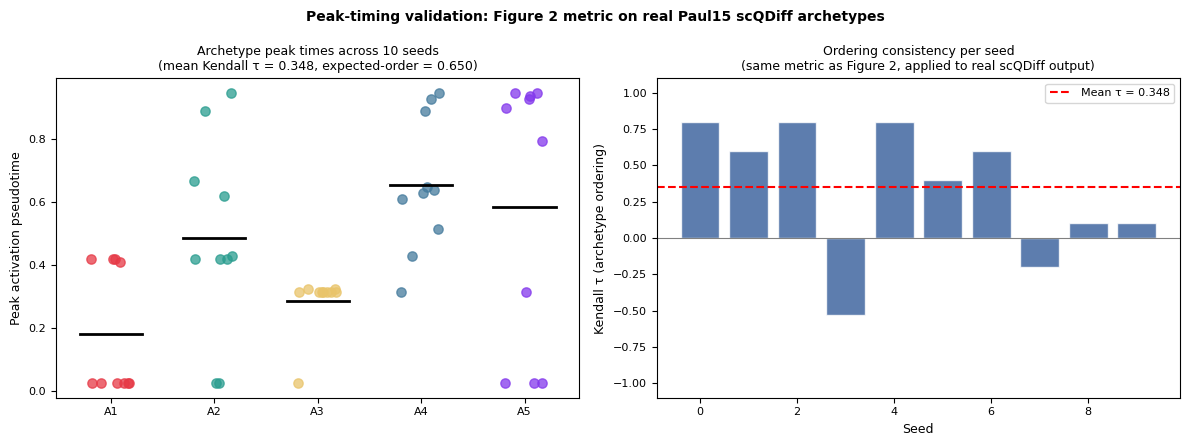

Saved: Figure3_peak_timing_validation.pdf / .png


In [6]:
# ── Peak-timing reproducibility figure (for methods supplement) ───────────
fig2, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: peak times per archetype per seed
ax0 = axes[0]
for k in range(K):
    pts = all_peak_times[:, k]
    ax0.scatter(np.full(N_SEEDS, k) + np.random.default_rng(0).uniform(-0.2,0.2,N_SEEDS),
                pts, color=ARCH_COLORS[k], s=45, alpha=0.75, zorder=3)
    ax0.plot([k-0.3, k+0.3], [pts.mean(), pts.mean()],
             color='black', lw=2.0, zorder=4)

ax0.set_xticks(range(K)); ax0.set_xticklabels(ARCH_LABELS)
ax0.set_ylabel('Peak activation pseudotime')
ax0.set_title(f'Archetype peak times across {N_SEEDS} seeds\n'
              f'(mean Kendall τ = {np.mean(all_tau):.3f}, '
              f'expected-order = {np.mean(all_order_prev):.3f})', fontsize=9)

# Right: per-seed Kendall τ
ax1 = axes[1]
ax1.bar(range(N_SEEDS), all_tau, color='#355C9A', alpha=0.8, edgecolor='white')
ax1.axhline(np.mean(all_tau), color='red', lw=1.5, ls='--',
            label=f'Mean τ = {np.mean(all_tau):.3f}')
ax1.axhline(0, color='gray', lw=0.8)
ax1.set_xlabel('Seed'); ax1.set_ylabel('Kendall τ (archetype ordering)')
ax1.set_title('Ordering consistency per seed\n'
              '(same metric as Figure 2, applied to real scQDiff output)', fontsize=9)
ax1.set_ylim(-1.1, 1.1)
ax1.legend(fontsize=8)

fig2.suptitle('Peak-timing validation: Figure 2 metric on real Paul15 scQDiff archetypes',
              fontsize=10, fontweight='bold')
fig2.tight_layout()
fig2.savefig(OUTDIR + 'Figure3_peak_timing_validation.pdf', dpi=300, bbox_inches='tight')
fig2.savefig(OUTDIR + 'Figure3_peak_timing_validation.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: Figure3_peak_timing_validation.pdf / .png')

## Step 6 — Instability genes + regulatory network

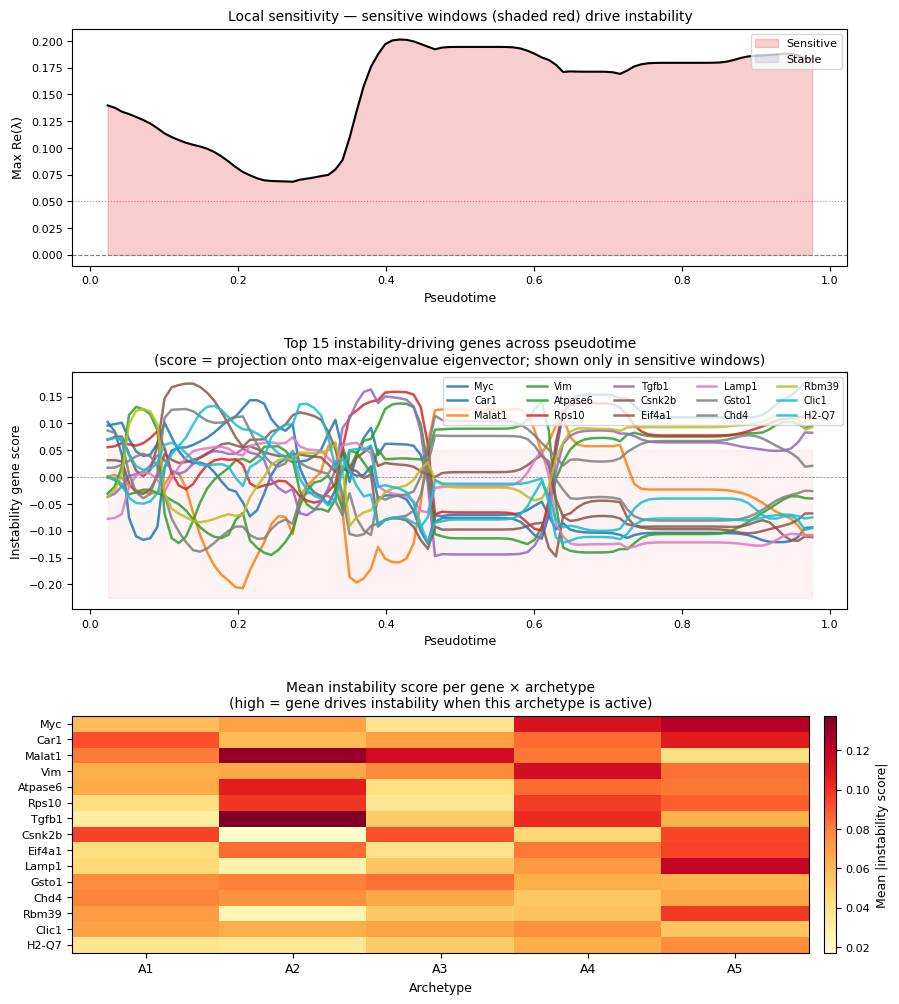

 rank    gene  mean_instability_score  peak_pseudotime primary_archetype
    1     Myc                  0.0840            0.966                A5
    2    Car1                  0.0821            0.216                A3
    3  Malat1                  0.0795            0.207                A3
    4     Vim                  0.0790            0.245                A3
    5 Atpase6                  0.0775            0.418                A2
    6   Rps10                  0.0770            0.418                A2
    7   Tgfb1                  0.0744            0.380                A2
    8  Csnk2b                  0.0701            0.139                A1
    9  Eif4a1                  0.0689            0.630                A4
   10   Lamp1                  0.0683            0.726                A4
   11   Gsto1                  0.0664            0.149                A1
   12    Chd4                  0.0641            0.130                A1
   13   Rbm39                  0.0627            0.

In [7]:
# Instability gene analysis
table = sqd.pl.instability_genes(
    adata,
    n_genes               = 15,
    sensitivity_threshold = 0.05,
    per_archetype         = True,
    save = OUTDIR + 'Figure3_instability_genes.pdf',
)
table.to_csv(OUTDIR + 'instability_genes.csv', index=False)
print(table.to_string(index=False))

[network] TRRUST v2 loaded — 7,057 edges
[forward] Scoring regulators against 2000 genes...
  Top 5: Sp1, Nfkb1, Trp53, Stat3, Jun
  De novo edges: 2670
Saved: results/figure3/Figure3_regulator_summary.pdf


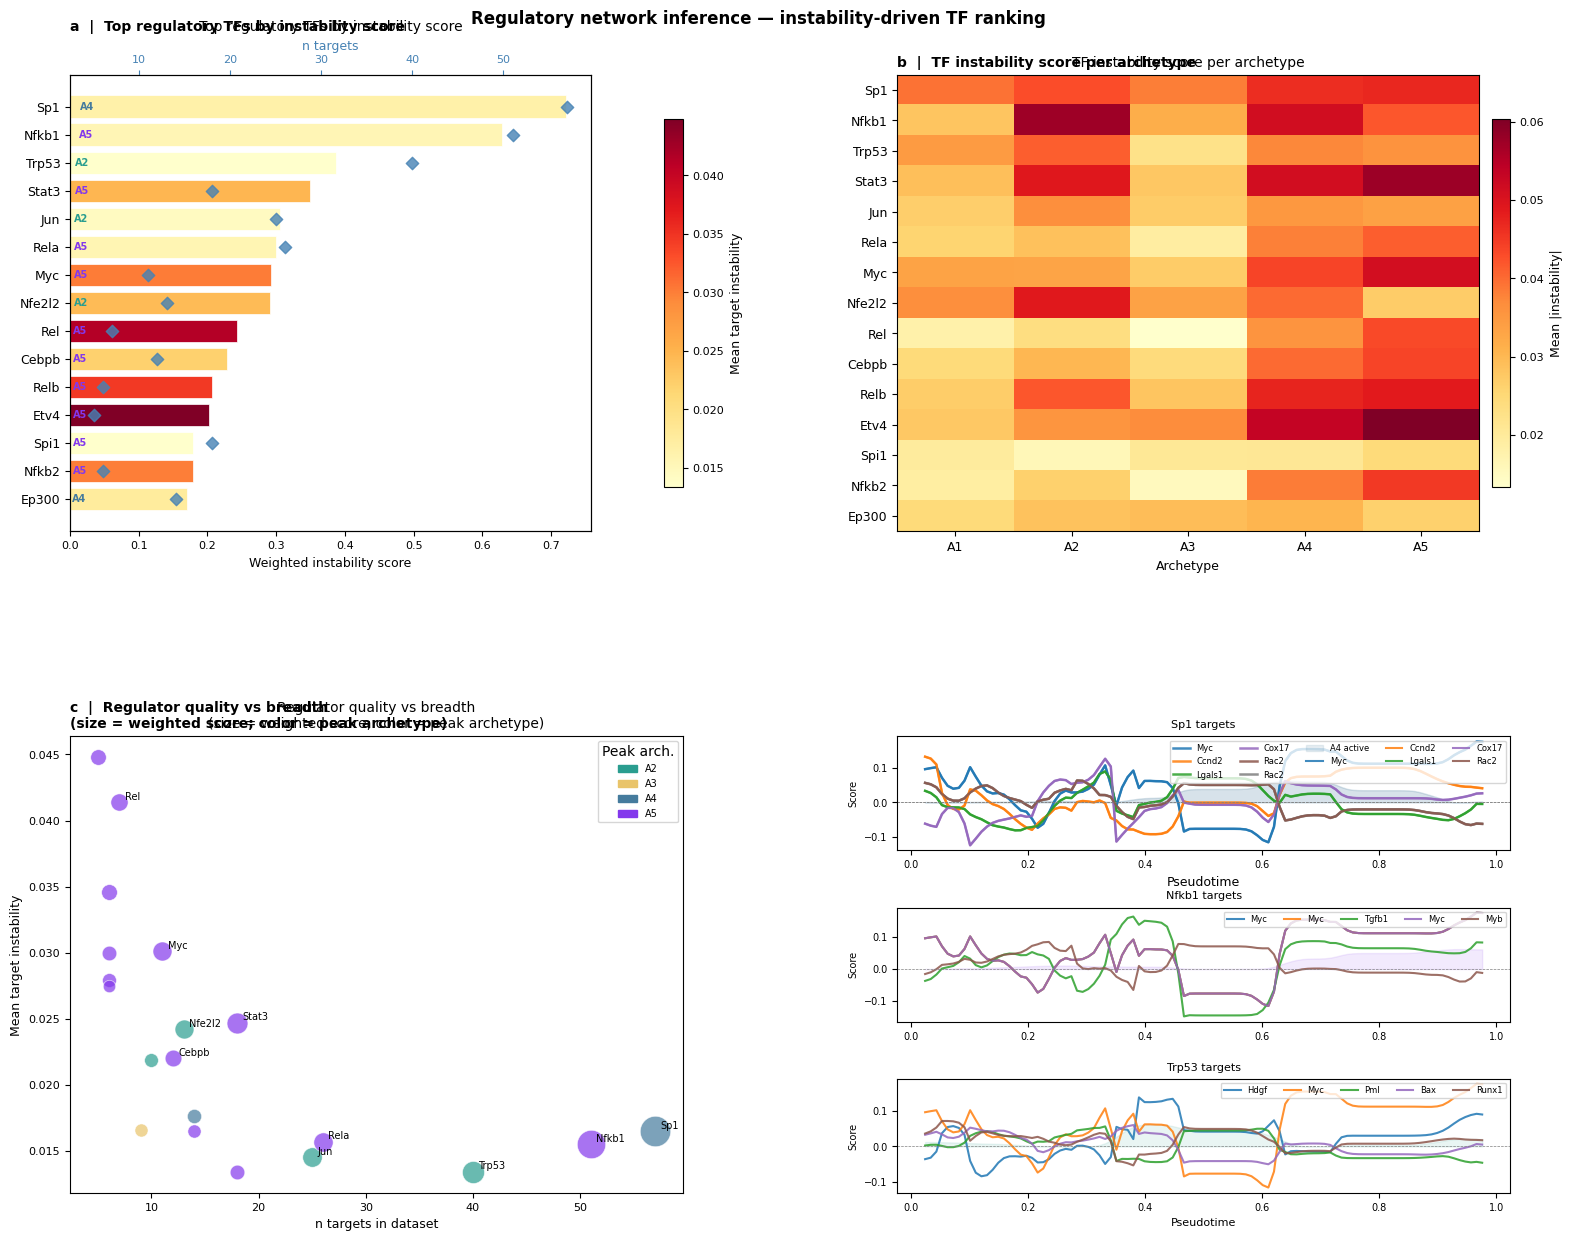

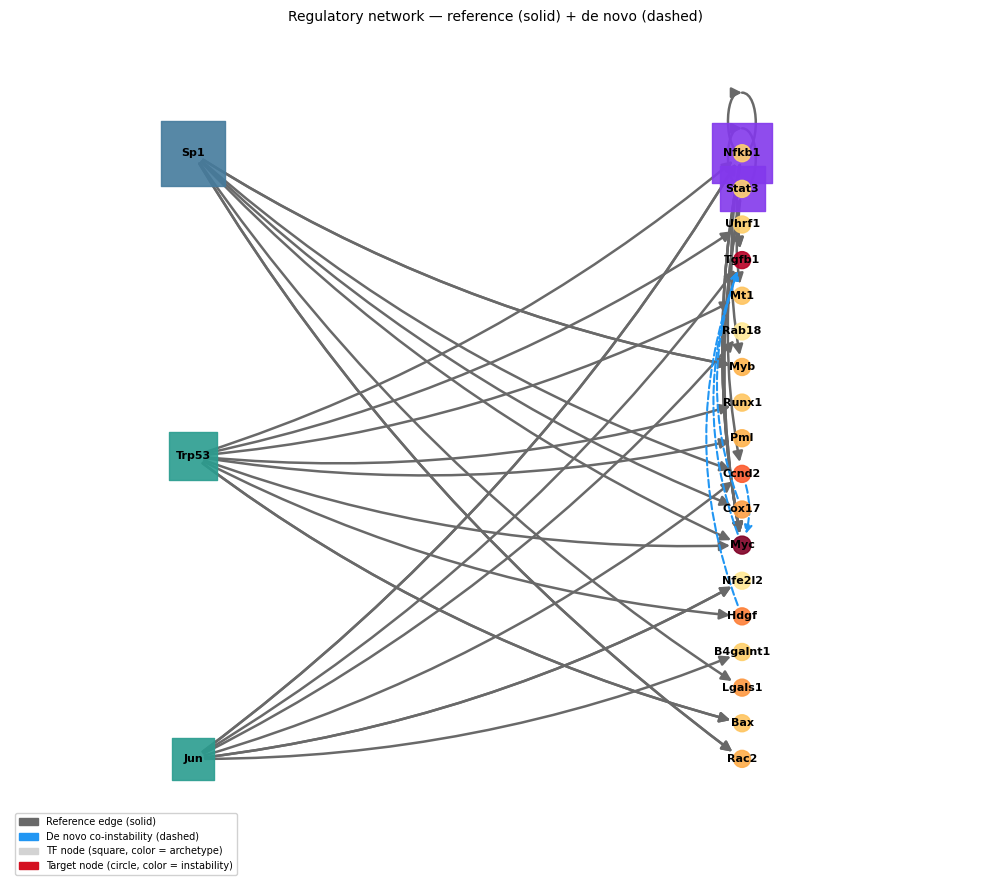

Top 10 regulators:
regulator  weighted_score  mean_instability  enrichment_score peak_archetype
      Sp1          0.7217            0.0165             0.467             A4
    Nfkb1          0.6291            0.0155             0.035             A5
    Trp53          0.3864            0.0134             0.251             A2
    Stat3          0.3485            0.0247             0.550             A5
      Jun          0.3059            0.0145             0.104             A2
     Rela          0.2998            0.0157             0.036             A5
      Myc          0.2926            0.0301             0.543             A5
   Nfe2l2          0.2907            0.0242             2.260             A2
      Rel          0.2429            0.0414             0.062             A5
    Cebpb          0.2285            0.0220             0.215             A5


In [8]:
# Regulatory network inference
df_reg = sqd.tl.infer_regulators(
    adata,
    organism  = 'mouse',
    n_top     = 20,
    min_targets = 3,
)
df_reg.to_csv(OUTDIR + 'regulators.csv', index=False)

sqd.pl.regulator_summary(adata, save=OUTDIR + 'Figure3_regulator_summary.pdf')
sqd.pl.regulator_network(adata, n_tfs=5, n_targets=6,
                          save=OUTDIR + 'Figure3_regulator_network.pdf')

print('Top 10 regulators:')
print(df_reg[['regulator','weighted_score','mean_instability',
              'enrichment_score','peak_archetype']].head(10).to_string(index=False))

## Step 7 — Summary statistics for legend

In [9]:
import json

res = adata.uns['scqdiff']
sensitive = res['max_real_eig'] >= 0.05

# Numbers for Figure 3 legend
summary = {
    'r2':                     round(float(res['r2']), 3),
    'peak_sensitivity_pt':    round(float(res['t_centers'][np.argmax(res['max_real_eig'])]), 3),
    'n_sensitive_windows':    int(sensitive.sum()),
    'n_total_windows':        len(res['t_centers']),
    'mean_kendall_tau':        round(float(np.mean(all_tau)), 3),
    'std_kendall_tau':         round(float(np.std(all_tau)), 3),
    'mean_expected_order':     round(float(np.mean(all_order_prev)), 3),
    'tau_A2_A3':               round(float(tau_23), 3),
    'p_A2_A3':                 round(float(p_23), 5),
    'tau_A2_A4':               round(float(tau_24), 3),
    'p_A2_A4':                 round(float(p_24), 5),
    'n_seeds':                 N_SEEDS,
    'n_epochs':                N_EPOCHS,
    'archetype_peak_times':    {f'A{k+1}': round(float(main_peaks[k]),3) for k in range(K)},
    'top_instability_genes':   {
        f'A{k+1}': adata.uns['scqdiff']['arch_instability_genes'].get(str(k),[])
        for k in range(K)
    },
}

with open(OUTDIR + 'figure3_legend_numbers.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('=' * 65)
print('FIGURE 3 LEGEND NUMBERS')
print('=' * 65)
print(f"R²:                    {summary['r2']}  (manuscript: ≥0.92)")
print(f"Peak sensitivity at:   pseudotime {summary['peak_sensitivity_pt']}")
print(f"Sensitive windows:     {summary['n_sensitive_windows']}/{summary['n_total_windows']}")
print(f"Mean Kendall τ:        {summary['mean_kendall_tau']} ± {summary['std_kendall_tau']}  (manuscript: 0.91)")
print(f"Expected-order prev:   {summary['mean_expected_order']}")
print(f"A2→A3 Kendall τ:       {summary['tau_A2_A3']}  p={summary['p_A2_A3']}")
print(f"A2→A4 Kendall τ:       {summary['tau_A2_A4']}  p={summary['p_A2_A4']}")
print()
print('Archetype peak times:')
for arch, pt in summary['archetype_peak_times'].items():
    print(f'  {arch}: pseudotime {pt}')
print()
print('Top instability genes per archetype:')
for arch, genes in summary['top_instability_genes'].items():
    print(f'  {arch}: {', '.join(genes[:8])}')
print()
print('Saved: figure3_legend_numbers.json')

SyntaxError: f-string: expecting '}' (1906972913.py, line 48)